# Where Is Malaysia's Labour Market Actually Weakest?

## The Question

Notebooks 01–03 established the national and age-based picture. This notebook shifts to geography: across every one of Malaysia's 16 states and federal territories, where is unemployment actually concentrated, and is the pattern what you'd casually expect (poorer, more rural states worse off), or something less obvious?

## The Answer

Mostly, unemployment is highest in Malaysia's less-industrialised, more rural states; Sabah (5.7%), Kelantan (4.6%), and Perak (3.7%) top the ranking, while industrial, urbanised states like Selangor (1.8%) and Penang (2.7%) run well below the national rate. That's the expected pattern. The genuine exception is Kuala Lumpur: Malaysia's wealthiest city per capita posts 3.2%, slightly *above* the national rate, breaking the pattern every other industrialised state follows, a wrinkle Notebook 05 digs into directly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
state_q = pd.read_csv('../data/processed/state_unemployment_quarterly.csv')
state_q['date'] = pd.to_datetime(state_q['date'])
latest_q = state_q['date'].max()
latest = state_q[state_q['date'] == latest_q].sort_values('u_rate', ascending=False)
latest[['state', 'u_rate', 'p_rate']]

,state,u_rate,p_rate
419,Sabah,5.7,70.5
524,W.P. Labuan,4.7,66.3
104,Kelantan,4.6,59.8
279,Perak,3.7,67.7
314,Perlis,3.2,63.0
489,W.P. Kuala Lumpur,3.2,75.6
454,Sarawak,3.1,69.5
174,Negeri Sembilan,3.0,67.4
384,Terengganu,2.9,60.8
244,Pulau Pinang,2.7,71.3


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Every state and federal territory, ranked by unemployment rate

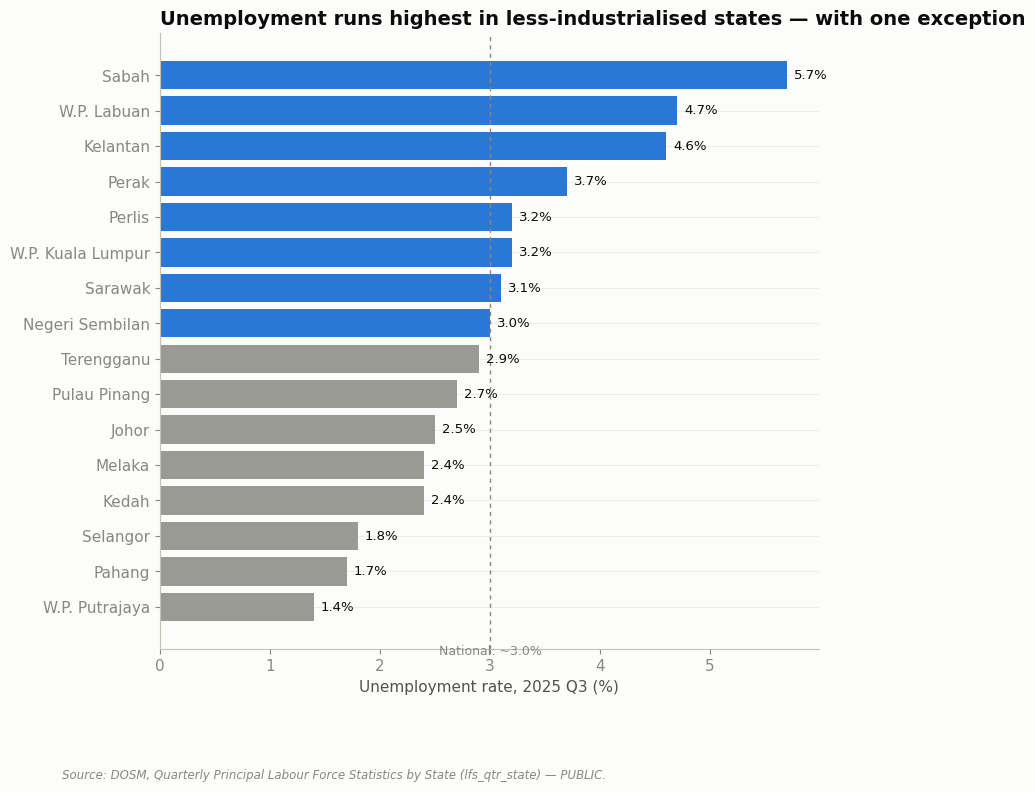

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 8))
latest_sorted = latest.sort_values('u_rate')
national_u = 3.0
colors = [ACCENT_1 if v >= national_u else GRAY for v in latest_sorted['u_rate']]
bars = ax.barh(latest_sorted['state'], latest_sorted['u_rate'], color=colors)
for b in bars:
    ax.annotate(f'{b.get_width():.1f}%', xy=(b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=9.5)
ax.axvline(national_u, color=INK_MUTED, linewidth=1, linestyle=(0, (3, 3)))
ax.annotate('National: ~3.0%', xy=(national_u, -0.8), xytext=(0, -14), textcoords='offset points',
            fontsize=9, color=INK_MUTED, ha='center')
ax.set_title('Unemployment runs highest in less-industrialised states \u2014 with one exception', loc='left')
ax.set_xlabel(f'Unemployment rate, {latest_q.strftime("%Y Q")}{(latest_q.month-1)//3+1} (%)')
add_source(ax.figure, 'Source: DOSM, Quarterly Principal Labour Force Statistics by State (lfs_qtr_state) \u2014 PUBLIC.')
plt.show()

## Strategic Recommendation

- **The broad pattern is the expected one (industrialised states do better) so the interesting, decision-relevant signal isn't the pattern, it's the exception.** A business benchmarking Kuala Lumpur against Selangor or Penang as if they're interchangeable "Klang Valley" labour markets shouldn't; KL's unemployment rate doesn't track with regional wealth or industrial strength the way its neighbours' do.
- **This notebook only establishes *where*; Notebook 05 tests *why* KL specifically breaks the pattern.**

## Confidence & Caveats

- **This is general unemployment, not graduate-specific.** DOSM does not publish a state-by-education-level breakdown, so this layer (and Notebook 06) test the geography of the *general* labour market, which the national layers (01–03) argue is a reasonable proxy given graduates track the national rate closely.
- **A single quarter is a snapshot, not a trend**; state rankings can shift quarter to quarter; the processed data retains the full 2017–present quarterly series for anyone who wants to check stability over time.